# X-Space Group GPR Split Summary

This notebook reproduces the X-space group split and manual GPR workflow from `XSpaceGroupGPR.ipynb`, using the same random seed and model settings. The output is intentionally compact: only test-set metrics are displayed, followed by a functional split classification table.

Functional classes:

- `Precise Prediction`: suitable for numerical prediction.
- `Applied Ranking`: not precise enough for calibrated numerical prediction, but useful for ranking/screening candidates.
- `Applied Ranking - Weak`: some trend is present, but ranking evidence is not strong enough for the main applied-ranking class.
- `Bad Performance`: numerical prediction and/or ranking are unreliable.

## Settings and imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Keep display compact but wide enough for the final reason table.
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 260)
pd.set_option("display.width", 220)

WORK_DIR = Path("/mnt/d/Homedrive(local_copy)/JiayiWork")
if not WORK_DIR.exists():
    WORK_DIR = Path.cwd()

EXPORT_FIGURES = False
FIGURE_DIR = WORK_DIR / "figures" / "xspace_gpr_summary"


def apply_nature_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "svg.fonttype": "none",
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.9,
        "axes.grid": False,
        "legend.frameon": False,
    })


def save_figure_if_requested(fig, name):
    if not EXPORT_FIGURES:
        return []
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in ["svg", "pdf"]:
        out = FIGURE_DIR / f"{name}.{ext}"
        fig.savefig(out, bbox_inches="tight")
        saved.append(out)
    return saved


apply_nature_style()

CLASSIFICATION_COLORS = {
    "Precise Prediction": "#0F4D92",
    "Applied Ranking": "#42949E",
    "Applied Ranking - Weak": "#9A4D8E",
    "Bad Performance": "#B64342",
}

DATA_FILE = WORK_DIR / "Area H TC TimeLOG Model.xlsx"
target = "Target"
manual_features = ["P", "I", "D"]
missing = -99999

x_group_distance_threshold = 0.6
n_splits = 20
test_size = 0.3
random_state = 42
candidate_attempts = 5000

length_scales_start = 1
length_scale_lims = (1, 10000)
normalize_y = True
stable_fraction = 0.20

if not DATA_FILE.exists():
    raise FileNotFoundError(DATA_FILE)

print(f"work dir: {WORK_DIR}")
print(f"data file: {DATA_FILE}")
print(f"EXPORT_FIGURES: {EXPORT_FIGURES}")

work dir: /mnt/d/Homedrive(local_copy)/JiayiWork
data file: /mnt/d/Homedrive(local_copy)/JiayiWork/Area H TC TimeLOG Model.xlsx
EXPORT_FIGURES: False


## Load and prepare data

In [3]:
df_raw = pd.read_excel(DATA_FILE)
df_numeric = df_raw.select_dtypes(include="number").copy()
df_numeric.replace(to_replace=missing, value=np.nan, inplace=True)

required_columns = manual_features + [target]
missing_columns = [c for c in required_columns if c not in df_numeric.columns]
if missing_columns:
    raise KeyError(f"Missing required numeric columns: {missing_columns}")

df_model = df_numeric.loc[:, required_columns].dropna().reset_index(drop=True)
if df_model.empty:
    raise ValueError("No rows remain after dropping missing P/I/D/Target values.")

normalize_y_effective = bool(normalize_y)
if normalize_y and float(df_model[target].mean()) <= 0:
    normalize_y_effective = False
    print(
        f"normalize_y requested, but disabled because mean({target})="
        f"{df_model[target].mean():.6f} <= 0. This matches the original notebook policy."
    )

print(f"raw shape: {df_raw.shape}")
print(f"model shape after dropping rows with missing required values: {df_model.shape}")
print(f"features: {manual_features}")
print(f"target mean: {df_model[target].mean():.6f}")
print(f"normalize_y_effective: {normalize_y_effective}")

normalize_y requested, but disabled because mean(Target)=-0.744124 <= 0. This matches the original notebook policy.
raw shape: (51, 25)
model shape after dropping rows with missing required values: (51, 4)
features: ['P', 'I', 'D']
target mean: -0.744124
normalize_y_effective: False


## Reproduce X-space groups

In [4]:
X_group_raw = df_model.loc[:, manual_features].to_numpy(dtype=float)
X_group_scaled = StandardScaler().fit_transform(X_group_raw)
X_group_scaled_df = pd.DataFrame(
    X_group_scaled,
    index=df_model.index,
    columns=[f"{feature}_z" for feature in manual_features],
)

x_group_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=x_group_distance_threshold,
    linkage="complete",
)
df_model["x_group"] = x_group_model.fit_predict(X_group_scaled).astype(int)


def max_pairwise_distance_for_group(group):
    scaled_values = X_group_scaled_df.loc[group.index].to_numpy(dtype=float)
    if len(scaled_values) < 2:
        return 0.0
    diff = scaled_values[:, None, :] - scaled_values[None, :, :]
    distances = np.sqrt(np.sum(diff ** 2, axis=2))
    return float(np.max(distances))


x_group_distance_summary = (
    df_model.groupby("x_group")
    .apply(max_pairwise_distance_for_group)
    .rename("max_pairwise_distance_scaled_PID")
    .reset_index()
)

group_sizes = df_model["x_group"].value_counts().sort_index()
actual_x_groups = int(df_model["x_group"].nunique())
singleton_group_count = int((group_sizes == 1).sum())
largest_group_fraction = float(group_sizes.max() / len(df_model))
max_observed_group_distance = float(x_group_distance_summary["max_pairwise_distance_scaled_PID"].max())

if max_observed_group_distance > x_group_distance_threshold + 1e-9:
    raise AssertionError(
        "Complete-linkage grouping produced a group with max pairwise distance "
        f"{max_observed_group_distance:.6g} > threshold {x_group_distance_threshold:.6g}."
    )

print(
    "X-space grouping reproduced: complete linkage on standardized P/I/D, "
    f"distance threshold={x_group_distance_threshold}."
)
print(f"Actual x_group count: {actual_x_groups}")
print(f"Singleton x_group count: {singleton_group_count}")
print(f"Largest x_group fraction: {largest_group_fraction:.3f}")
print(f"Maximum observed within-group pairwise distance: {max_observed_group_distance:.3f}")

X-space grouping reproduced: complete linkage on standardized P/I/D, distance threshold=0.6.
Actual x_group count: 26
Singleton x_group count: 15
Largest x_group fraction: 0.118
Maximum observed within-group pairwise distance: 0.591


/tmp/ipykernel_1522971/621856041.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(max_pairwise_distance_for_group)


## Reproduce 20 grouped splits

In [5]:
def generate_xgroup_splits(
    df,
    group_col,
    n_splits=20,
    test_size=0.3,
    random_state=42,
    candidate_attempts=5000,
):
    rng = np.random.default_rng(random_state)
    n_samples = len(df)
    unique_groups = np.array(sorted(df[group_col].unique()))
    group_sizes_local = df.groupby(group_col).size().to_dict()
    all_indices = np.arange(n_samples)

    accepted = []
    used_test_group_signatures = set()

    for split_index in range(n_splits):
        best_candidate = None
        best_score = None

        for _ in range(candidate_attempts):
            shuffled_groups = rng.permutation(unique_groups)
            test_groups = []
            test_count = 0

            for group_id in shuffled_groups:
                proposed_count = test_count + int(group_sizes_local[group_id])
                current_gap = abs(test_count / n_samples - test_size)
                proposed_gap = abs(proposed_count / n_samples - test_size)
                if not test_groups or proposed_gap <= current_gap:
                    test_groups.append(int(group_id))
                    test_count = proposed_count
                if test_count / n_samples >= test_size:
                    break

            signature = tuple(sorted(test_groups))
            if signature in used_test_group_signatures:
                continue

            is_test = df[group_col].isin(test_groups).to_numpy()
            test_idx = all_indices[is_test]
            train_idx = all_indices[~is_test]
            if len(train_idx) == 0 or len(test_idx) == 0:
                continue

            train_groups = sorted(df.iloc[train_idx][group_col].unique().astype(int).tolist())
            test_groups_sorted = sorted(test_groups)
            x_group_overlap = sorted(set(train_groups) & set(test_groups_sorted))
            test_fraction = len(test_idx) / n_samples
            score = (
                abs(test_fraction - test_size),
                abs(len(test_groups_sorted) - round(len(unique_groups) * test_size)),
                len(x_group_overlap),
            )

            candidate = {
                "split_index": split_index,
                "train_idx": train_idx,
                "test_idx": test_idx,
                "train_x_groups": train_groups,
                "test_x_groups": test_groups_sorted,
                "x_group_overlap": x_group_overlap,
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "test_fraction": float(test_fraction),
            }

            if best_score is None or score < best_score:
                best_score = score
                best_candidate = candidate

        if best_candidate is None:
            raise RuntimeError(
                "Could not generate enough grouped splits. Try increasing candidate_attempts "
                "or changing x_group_distance_threshold/test_size."
            )

        used_test_group_signatures.add(tuple(best_candidate["test_x_groups"]))
        accepted.append(best_candidate)

    return accepted


grouped_splits = generate_xgroup_splits(
    df_model,
    "x_group",
    n_splits=n_splits,
    test_size=test_size,
    random_state=random_state,
    candidate_attempts=candidate_attempts,
)

split_diagnostics = pd.DataFrame([
    {
        "split_index": split["split_index"],
        "n_train": split["n_train"],
        "n_test": split["n_test"],
        "test_fraction": split["test_fraction"],
        "train_x_groups": split["train_x_groups"],
        "test_x_groups": split["test_x_groups"],
        "x_group_overlap": split["x_group_overlap"],
        "n_x_group_overlap": len(split["x_group_overlap"]),
    }
    for split in grouped_splits
])

print("Grouped splits reproduced with the original random seed.")
display(split_diagnostics[["split_index", "n_train", "n_test", "test_fraction", "test_x_groups", "n_x_group_overlap"]])

Grouped splits reproduced with the original random seed.


,split_index,n_train,n_test,test_fraction,test_x_groups,n_x_group_overlap
0,0,36,15,0.294118,"[5, 6, 8, 10, 11, 17, 18, 25]",0
1,1,36,15,0.294118,"[1, 12, 15, 16, 20, 21, 22, 25]",0
2,2,36,15,0.294118,"[1, 2, 7, 14, 16, 17, 19, 23]",0
3,3,36,15,0.294118,"[0, 2, 8, 18, 19, 23, 24, 25]",0
4,4,36,15,0.294118,"[1, 7, 11, 16, 18, 19, 24, 25]",0
5,5,36,15,0.294118,"[1, 6, 11, 14, 17, 18, 19, 23]",0
6,6,36,15,0.294118,"[5, 6, 7, 10, 12, 14, 19, 24]",0
7,7,36,15,0.294118,"[1, 4, 13, 14, 17, 18, 22, 23]",0
8,8,36,15,0.294118,"[3, 4, 14, 16, 18, 20, 24, 25]",0
9,9,36,15,0.294118,"[3, 6, 7, 9, 16, 20, 24, 25]",0


## Train GPR and collect test-only metrics

In [6]:
def safe_rank_corr(y_true, y_pred):
    if len(y_true) < 2 or len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        return np.nan, np.nan
    spearman = stats.spearmanr(y_true, y_pred).correlation
    kendall = stats.kendalltau(y_true, y_pred).correlation
    return float(spearman), float(kendall)


def pairwise_order_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    correct = 0
    comparable = 0
    for i in range(len(y_true)):
        for j in range(i + 1, len(y_true)):
            true_diff = y_true[i] - y_true[j]
            pred_diff = y_pred[i] - y_pred[j]
            if true_diff == 0 or pred_diff == 0:
                continue
            comparable += 1
            if np.sign(true_diff) == np.sign(pred_diff):
                correct += 1
    return float(correct / comparable) if comparable else np.nan


def evaluate_manual_gpr_xgroup_splits_test_only(
    df,
    features,
    target_col,
    grouped_splits,
    stable_fraction=0.20,
    length_scales_start=1,
    length_scale_lims=(1, 10000),
    normalize_y=False,
):
    X_raw = df.loc[:, features].to_numpy(dtype=float)
    y_raw = df.loc[:, target_col].to_numpy(dtype=float)
    x_groups = df["x_group"].to_numpy()

    valid = np.isfinite(y_raw) & np.all(np.isfinite(X_raw), axis=1)
    if not np.all(valid):
        raise ValueError("Unexpected non-finite values after preprocessing.")

    rows = []
    prediction_rows = []

    for split in grouped_splits:
        split_index = int(split["split_index"])
        train_idx = np.asarray(split["train_idx"], dtype=int)
        test_idx = np.asarray(split["test_idx"], dtype=int)

        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]
        y_train_raw = y_raw[train_idx]
        y_test_raw = y_raw[test_idx]

        X_train_std = X_train_raw.std(axis=0)
        if np.any(X_train_std == 0):
            zero_var = [f for f, s in zip(features, X_train_std) if s == 0]
            raise ValueError(f"Zero-variance feature(s) in split {split_index}: {zero_var}")

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        y_mean = float(y_train_raw.mean())
        if normalize_y and y_mean <= 0:
            raise ValueError(
                f"normalize_y=True but split {split_index} train mean({target_col})={y_mean:.6g} <= 0."
            )
        y_train_fit = y_train_raw / y_mean if normalize_y else y_train_raw.copy()

        kernel = 1.0 * RBF(
            length_scale=[length_scales_start for _ in features],
            length_scale_bounds=[length_scale_lims for _ in features],
        ) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-10, 1000))
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0)
        gp.fit(X_train, y_train_fit)

        y_test_pred_fit = gp.predict(X_test)
        y_test_pred = y_test_pred_fit * y_mean if normalize_y else y_test_pred_fit

        rmse_test = float(np.sqrt(mean_squared_error(y_test_raw, y_test_pred)))
        mae_test = float(mean_absolute_error(y_test_raw, y_test_pred))
        r2_test = float(r2_score(y_test_raw, y_test_pred))
        spearman, kendall = safe_rank_corr(y_test_raw, y_test_pred)
        pair_acc = pairwise_order_accuracy(y_test_raw, y_test_pred)

        rows.append({
            "split_index": split_index,
            "n_test": int(len(test_idx)),
            "RMSE_test": rmse_test,
            "MAE_test": mae_test,
            "R2_test": r2_test,
            "spearman_rank_corr": spearman,
            "kendall_tau": kendall,
            "pairwise_order_accuracy": pair_acc,
            "negative_R2_test": bool(r2_test < 0),
        })

        y_order_true = stats.rankdata(y_test_raw, method="average")
        y_order_pred = stats.rankdata(y_test_pred, method="average")
        for local_pos, row_position in enumerate(test_idx):
            prediction_rows.append({
                "split_index": split_index,
                "row_position": int(row_position),
                "x_group": int(x_groups[row_position]),
                "y_true": float(y_test_raw[local_pos]),
                "y_pred": float(y_test_pred[local_pos]),
                "abs_error": float(abs(y_test_raw[local_pos] - y_test_pred[local_pos])),
                "squared_error": float((y_test_raw[local_pos] - y_test_pred[local_pos]) ** 2),
                "true_rank_low_target_first": float(y_order_true[local_pos]),
                "pred_rank_low_target_first": float(y_order_pred[local_pos]),
            })

    return pd.DataFrame(rows), pd.DataFrame(prediction_rows)


test_metrics_by_split, test_predictions = evaluate_manual_gpr_xgroup_splits_test_only(
    df=df_model,
    features=manual_features,
    target_col=target,
    grouped_splits=grouped_splits,
    stable_fraction=stable_fraction,
    length_scales_start=length_scales_start,
    length_scale_lims=length_scale_lims,
    normalize_y=normalize_y_effective,
)

metric_display_cols = [
    "split_index", "n_test", "RMSE_test", "MAE_test", "R2_test",
    "spearman_rank_corr", "kendall_tau", "pairwise_order_accuracy",
]

print("Test-set metrics only; Spearman is the primary ranking metric and pairwise ordering is retained as a secondary check:")
display(test_metrics_by_split[metric_display_cols].round(6))

Test-set metrics only; Spearman is the primary ranking metric and pairwise ordering is retained as a secondary check:


/home/imeetwsl/miniconda3/envs/hmrmr-gpr/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10000. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/imeetwsl/miniconda3/envs/hmrmr-gpr/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,split_index,n_test,RMSE_test,MAE_test,R2_test,spearman_rank_corr,kendall_tau,pairwise_order_accuracy
0,0,15,0.406925,0.304854,0.171797,0.650000,0.447619,0.723810
1,1,15,0.304887,0.189882,-0.106000,-0.235714,-0.180952,0.409524
2,2,15,0.251064,0.189234,0.601609,0.507143,0.409524,0.704762
3,3,15,0.184697,0.143877,0.708296,0.628571,0.504762,0.752381
4,4,15,0.251812,0.195437,0.279299,0.532143,0.409524,0.704762
5,5,15,0.254019,0.177287,0.510260,0.467857,0.390476,0.695238
6,6,15,0.185650,0.141608,0.662279,0.607143,0.485714,0.742857
7,7,15,0.264768,0.183266,0.476037,0.617857,0.466667,0.733333
8,8,15,0.215812,0.158746,-1.987655,0.053571,0.066667,0.533333
9,9,15,0.210218,0.150857,0.527728,0.475000,0.352381,0.676190


## Compute compact X/Target coverage diagnostics

In [7]:
def compute_split_x_range_diagnostics(df, features, grouped_splits):
    rows = []
    for split in grouped_splits:
        split_index = int(split["split_index"])
        train = df.iloc[np.asarray(split["train_idx"], dtype=int)]
        test = df.iloc[np.asarray(split["test_idx"], dtype=int)]
        row = {"split_index": split_index}
        outside_features = []
        feature_excess_strings = []

        for feature in features:
            train_min = float(train[feature].min())
            train_max = float(train[feature].max())
            test_min = float(test[feature].min())
            test_max = float(test[feature].max())
            lower_excess = max(0.0, train_min - test_min)
            upper_excess = max(0.0, test_max - train_max)
            range_excess = lower_excess + upper_excess
            within = bool(test_min >= train_min and test_max <= train_max)

            row[f"{feature}_train_min"] = train_min
            row[f"{feature}_train_max"] = train_max
            row[f"{feature}_test_min"] = test_min
            row[f"{feature}_test_max"] = test_max
            row[f"{feature}_test_range_excess"] = range_excess
            row[f"{feature}_test_within_train_range"] = within

            if not within:
                outside_features.append(feature)
                feature_excess_strings.append(f"{feature} excess={range_excess:.3g}")

        row["n_features_outside_train_range"] = len(outside_features)
        row["outside_features"] = ", ".join(outside_features) if outside_features else "none"
        row["outside_feature_excess"] = "; ".join(feature_excess_strings) if feature_excess_strings else "none"
        row["all_test_features_within_train_range"] = len(outside_features) == 0
        rows.append(row)

    return pd.DataFrame(rows)


def compute_split_target_distribution_diagnostics(df, target_col, grouped_splits):
    rows = []
    for split in grouped_splits:
        split_index = int(split["split_index"])
        train_idx = np.asarray(split["train_idx"], dtype=int)
        test_idx = np.asarray(split["test_idx"], dtype=int)

        y_train = df.iloc[train_idx][target_col].to_numpy(dtype=float)
        y_test = df.iloc[test_idx][target_col].to_numpy(dtype=float)

        train_min = float(np.min(y_train))
        train_max = float(np.max(y_train))
        train_range = float(train_max - train_min)
        test_min = float(np.min(y_test))
        test_max = float(np.max(y_test))
        test_range = float(test_max - test_min)
        test_below_train_min = max(0.0, train_min - test_min)
        test_above_train_max = max(0.0, test_max - train_max)
        test_target_range_excess = test_below_train_min + test_above_train_max

        rows.append({
            "split_index": split_index,
            "train_target_min": train_min,
            "train_target_max": train_max,
            "train_target_range": train_range,
            "test_target_min": test_min,
            "test_target_max": test_max,
            "test_target_range": test_range,
            "test_target_std": float(np.std(y_test, ddof=1)) if len(y_test) > 1 else np.nan,
            "test_target_within_train_range": bool(test_min >= train_min and test_max <= train_max),
            "test_target_range_excess": test_target_range_excess,
            "test_target_mean_shift": float(np.mean(y_test) - np.mean(y_train)),
            "test_target_median_shift": float(np.median(y_test) - np.median(y_train)),
            "test_target_range_ratio_over_train": float(test_range / train_range) if train_range > 0 else np.nan,
        })

    return pd.DataFrame(rows)


split_x_range_diagnostics = compute_split_x_range_diagnostics(df_model, manual_features, grouped_splits)
split_target_distribution_diagnostics = compute_split_target_distribution_diagnostics(df_model, target, grouped_splits)

print("Compact coverage diagnostics computed for classification reasons.")

Compact coverage diagnostics computed for classification reasons.


## Classify splits by functional use

In [8]:
def classify_split(row):
    bad = (
        row["spearman_rank_corr"] < 0.20
        or (row["R2_test"] < 0 and row["pairwise_order_accuracy"] < 0.55)
    )
    if bad:
        return "Bad Performance"

    precise = (
        row["R2_test"] >= 0.50
        and row["RMSE_test"] <= 0.26
        and row["MAE_test"] <= 0.19
        and row["spearman_rank_corr"] >= 0.45
    )
    if precise:
        return "Precise Prediction"

    if row["spearman_rank_corr"] >= 0.45:
        return "Applied Ranking"

    if 0.20 <= row["spearman_rank_corr"] < 0.45 or row["pairwise_order_accuracy"] >= 0.55:
        return "Applied Ranking - Weak"

    return "Bad Performance"


def build_evidence_reason(row):
    x_text = (
        "all P/I/D test ranges are within the training ranges"
        if row["n_features_outside_train_range"] == 0
        else f"outside training range for {row['outside_features']} ({row['outside_feature_excess']})"
    )
    target_text = (
        "test Target range is within the training Target range"
        if row["test_target_within_train_range"]
        else f"test Target range exceeds training range by {row['test_target_range_excess']:.3f}"
    )

    base = (
        f"Prediction evidence: R2={row['R2_test']:.3f}, RMSE={row['RMSE_test']:.3f}, "
        f"MAE={row['MAE_test']:.3f}. Ranking evidence: Spearman={row['spearman_rank_corr']:.3f} "
        f"as the primary rank metric; pairwise order accuracy={row['pairwise_order_accuracy']:.3f} "
        f"as a secondary application-oriented check. X-space: {x_text}. "
        f"Target-space: {target_text}; test Target range={row['test_target_range']:.3f}, "
        f"test Target std={row['test_target_std']:.3f}."
    )

    if row["classification"] == "Precise Prediction":
        interpretation = (
            "This split supports calibrated numerical prediction because the test-set error is low, "
            "R2 is clearly positive, and Spearman indicates useful rank preservation."
        )
    elif row["classification"] == "Applied Ranking":
        interpretation = (
            "This split is better used for applied ranking: numerical calibration is not strong enough "
            "for the precise-prediction class, but Spearman supports practical candidate ordering."
        )
    elif row["classification"] == "Applied Ranking - Weak":
        interpretation = (
            "This split shows weak-to-moderate ranking utility; it may indicate trend information, "
            "but the ranking evidence is below the main applied-ranking threshold."
        )
    else:
        interpretation_parts = []
        if row["spearman_rank_corr"] < 0.20:
            interpretation_parts.append("Spearman below 0.20 indicates unreliable ranking")
        if row["R2_test"] < 0 and row["pairwise_order_accuracy"] < 0.55:
            interpretation_parts.append("negative R2 combined with weak pairwise ordering indicates poor prediction utility")
        if row["R2_test"] < 0 and row["RMSE_test"] <= 0.26:
            interpretation_parts.append(
                "R2 is poor despite moderate RMSE, likely because the test Target spread is narrow or baseline variance is small"
            )
        if row["n_features_outside_train_range"] > 0 or not row["test_target_within_train_range"]:
            interpretation_parts.append("prediction reliability is limited by X-space or Target-space extrapolation")
        interpretation = "; ".join(interpretation_parts) + "."

    return base + " " + interpretation


split_classification_summary = (
    test_metrics_by_split
    .merge(split_x_range_diagnostics, on="split_index", how="left")
    .merge(split_target_distribution_diagnostics, on="split_index", how="left")
)
split_classification_summary["classification"] = split_classification_summary.apply(classify_split, axis=1)
split_classification_summary["evidence_reason"] = split_classification_summary.apply(build_evidence_reason, axis=1)

classification_order = {
    "Precise Prediction": 0,
    "Applied Ranking": 1,
    "Applied Ranking - Weak": 2,
    "Bad Performance": 3,
}
split_classification_summary["classification_order"] = split_classification_summary["classification"].map(classification_order)
split_classification_summary = split_classification_summary.sort_values(
    ["classification_order", "spearman_rank_corr", "R2_test", "RMSE_test"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

classification_display_cols = [
    "split_index", "classification", "R2_test", "RMSE_test", "MAE_test",
    "spearman_rank_corr", "pairwise_order_accuracy",
    "n_features_outside_train_range", "outside_features", "test_target_within_train_range",
    "test_target_range_excess", "test_target_range", "test_target_std", "evidence_reason",
]

print("Split classification counts:")
display(split_classification_summary["classification"].value_counts().rename_axis("classification").reset_index(name="n_splits"))

Split classification counts:


,classification,n_splits
0,Applied Ranking,8
1,Precise Prediction,7
2,Bad Performance,4
3,Applied Ranking - Weak,1


## Display final split summary table

In [9]:
print("Functional split classification summary with evidence-backed reasons:")
display(split_classification_summary[classification_display_cols].round({
    "R2_test": 6,
    "RMSE_test": 6,
    "MAE_test": 6,
    "spearman_rank_corr": 6,
    "pairwise_order_accuracy": 6,
    "test_target_range_excess": 6,
    "test_target_range": 6,
    "test_target_std": 6,
}))

# Validation checks: final output columns intentionally contain test-set metrics only.
forbidden_training_cols = {"RMSE_train", "MAE_train", "R2_train", "RMSE_test_over_train"}
assert forbidden_training_cols.isdisjoint(metric_display_cols)
assert forbidden_training_cols.isdisjoint(classification_display_cols)
assert len(test_metrics_by_split) == n_splits
assert len(split_classification_summary) == n_splits
assert split_classification_summary["classification"].notna().all()
assert split_classification_summary["evidence_reason"].str.len().gt(0).all()
print("Validation passed: 20 splits classified, reasons are populated, and displayed columns exclude training metrics.")

Functional split classification summary with evidence-backed reasons:


,split_index,classification,R2_test,RMSE_test,MAE_test,spearman_rank_corr,pairwise_order_accuracy,n_features_outside_train_range,outside_features,test_target_within_train_range,test_target_range_excess,test_target_range,test_target_std,evidence_reason
0,10,Precise Prediction,0.775851,0.198909,0.149500,0.739286,0.800000,0,none,True,0.000000,1.243717,0.434878,"Prediction evidence: R2=0.776, RMSE=0.199, MAE=0.149. Ranking evidence: Spearman=0.739 as the primary rank metric; pairwise order accuracy=0.800 as a secondary application-oriented check. X-space: all P/I/D test ranges are within the training ranges. Targe..."
1,11,Precise Prediction,0.734093,0.156789,0.109962,0.675000,0.761905,0,none,True,0.000000,0.912621,0.314725,"Prediction evidence: R2=0.734, RMSE=0.157, MAE=0.110. Ranking evidence: Spearman=0.675 as the primary rank metric; pairwise order accuracy=0.762 as a secondary application-oriented check. X-space: all P/I/D test ranges are within the training ranges. Targe..."
2,3,Precise Prediction,0.708296,0.184697,0.143877,0.628571,0.752381,2,"P, I",True,0.000000,1.237092,0.353973,"Prediction evidence: R2=0.708, RMSE=0.185, MAE=0.144. Ranking evidence: Spearman=0.629 as the primary rank metric; pairwise order accuracy=0.752 as a secondary application-oriented check. X-space: outside training range for P, I (P excess=0.024; I excess=4..."
3,6,Precise Prediction,0.662279,0.185650,0.141608,0.607143,0.742857,1,D,True,0.000000,1.105564,0.330671,"Prediction evidence: R2=0.662, RMSE=0.186, MAE=0.142. Ranking evidence: Spearman=0.607 as the primary rank metric; pairwise order accuracy=0.743 as a secondary application-oriented check. X-space: outside training range for D (D excess=90). Target-space: t..."
4,2,Precise Prediction,0.601609,0.251064,0.189234,0.507143,0.704762,0,none,False,0.075978,1.319695,0.411730,"Prediction evidence: R2=0.602, RMSE=0.251, MAE=0.189. Ranking evidence: Spearman=0.507 as the primary rank metric; pairwise order accuracy=0.705 as a secondary application-oriented check. X-space: all P/I/D test ranges are within the training ranges. Targe..."
5,9,Precise Prediction,0.527728,0.210218,0.150857,0.475000,0.676190,0,none,True,0.000000,0.912621,0.316632,"Prediction evidence: R2=0.528, RMSE=0.210, MAE=0.151. Ranking evidence: Spearman=0.475 as the primary rank metric; pairwise order accuracy=0.676 as a secondary application-oriented check. X-space: all P/I/D test ranges are within the training ranges. Targe..."
6,5,Precise Prediction,0.510260,0.254019,0.177287,0.467857,0.695238,3,"P, I, D",False,0.075978,1.319695,0.375721,"Prediction evidence: R2=0.510, RMSE=0.254, MAE=0.177. Ranking evidence: Spearman=0.468 as the primary rank metric; pairwise order accuracy=0.695 as a secondary application-oriented check. X-space: outside training range for P, I, D (P excess=0.016; I exces..."
7,19,Applied Ranking,0.208263,0.395212,0.288572,0.650000,0.761905,1,D,False,0.208734,1.314298,0.459749,"Prediction evidence: R2=0.208, RMSE=0.395, MAE=0.289. Ranking evidence: Spearman=0.650 as the primary rank metric; pairwise order accuracy=0.762 as a secondary application-oriented check. X-space: outside training range for D (D excess=90). Target-space: t..."
8,0,Applied Ranking,0.171797,0.406925,0.304854,0.650000,0.723810,3,"P, I, D",False,0.389344,1.314298,0.462837,"Prediction evidence: R2=0.172, RMSE=0.407, MAE=0.305. Ranking evidence: Spearman=0.650 as the primary rank metric; pairwise order accuracy=0.724 as a secondary application-oriented check. X-space: outside training range for P, I, D (P excess=0.016; I exces..."
9,14,Applied Ranking,-0.239383,0.253951,0.181722,0.628571,0.714286,2,"I, D",True,0.000000,0.812392,0.236118,"Prediction evidence: R2=-0.239, RMSE=0.254, MAE=0.182. Ranking evidence: Spearman=0.629 as the primary rank metric; pairwise order accuracy=0.714 as a secondary application-oriented check. X-space: outside training range for I, D (I excess=38; D excess=2.8..."


Validation passed: 20 splits classified, reasons are populated, and displayed columns exclude training metrics.


## Visualization of split performance and trend prediction

These compact panels summarize the X-space grouping basis, Spearman-first functional classification, split-level performance patterns, and trend recovery. All performance panels use test-set predictions only. Lower `Target` indicates higher stability.

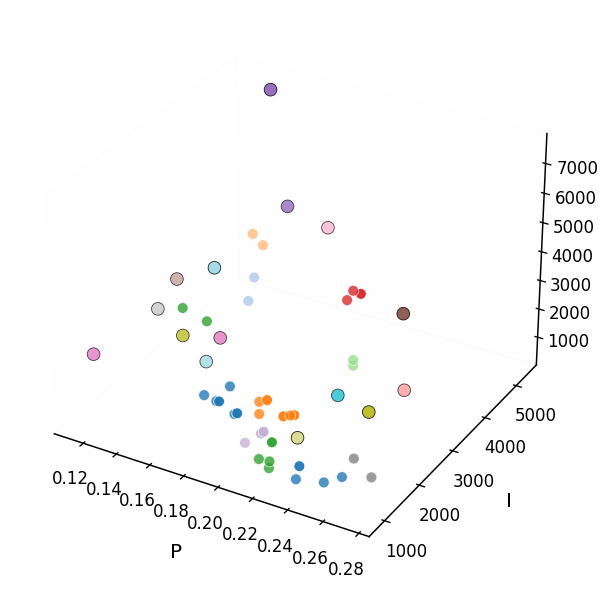

Figure note: The 3D X-space plot is a context panel showing P/I/D coverage and group structure, not a quantitative performance panel.


In [10]:
# 3D X-space group structure: grouped splits arise from sparse P/I/D coverage.
singleton_mask = df_model["x_group"].map(group_sizes).eq(1)
fig = plt.figure(figsize=(6.0, 5.0))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_model["P"],
    df_model["I"],
    df_model["D"],
    c=df_model["x_group"],
    cmap="tab20",
    s=np.where(singleton_mask, 58, 42),
    marker="o",
    edgecolor=np.where(singleton_mask, "black", "white"),
    linewidth=0.45,
    alpha=np.where(singleton_mask, 0.95, 0.78),
)
ax.set_xlabel("P", labelpad=8)
ax.set_ylabel("I", labelpad=8)
ax.set_zlabel("D", labelpad=8)
ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_alpha(0.04)
fig.tight_layout()
save_figure_if_requested(fig, "xspace_groups_3d")
plt.show()

print(
    "Figure note: The 3D X-space plot is a context panel showing P/I/D coverage and group structure, "
    "not a quantitative performance panel."
)

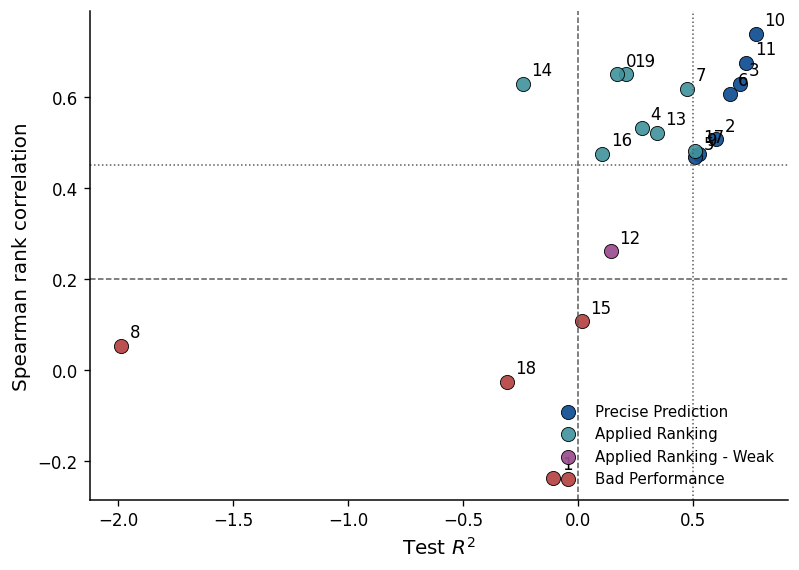

Figure note: Spearman is the primary ranking metric. Thresholds at 0.20 and 0.45 are operational cutoffs for unreliable and practically useful ranking, not universal statistical standards.


In [11]:
# Test R2 vs Spearman scatter: separates numerical prediction quality from ranking utility.
plot_df = split_classification_summary.copy()
fig, ax = plt.subplots(figsize=(6.8, 4.9))

for classification, group in plot_df.groupby("classification", sort=False):
    ax.scatter(
        group["R2_test"],
        group["spearman_rank_corr"],
        s=72,
        color=CLASSIFICATION_COLORS.get(classification, "0.4"),
        edgecolor="black",
        linewidth=0.55,
        alpha=0.92,
        label=classification,
    )
    for _, row in group.iterrows():
        ax.annotate(
            str(int(row["split_index"])),
            (row["R2_test"], row["spearman_rank_corr"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=10,
        )

ax.axvline(0, color="0.35", linestyle="--", linewidth=0.9)
ax.axvline(0.5, color="0.35", linestyle=":", linewidth=0.9)
ax.axhline(0.20, color="0.35", linestyle="--", linewidth=0.9)
ax.axhline(0.45, color="0.35", linestyle=":", linewidth=0.9)
ax.set_xlabel(r"Test $R^2$")
ax.set_ylabel("Spearman rank correlation")
ax.legend(loc="lower right", fontsize=9)
ax.grid(False)
fig.tight_layout()
save_figure_if_requested(fig, "r2_vs_spearman")
plt.show()

print(
    "Figure note: Spearman is the primary ranking metric. Thresholds at 0.20 and 0.45 are operational cutoffs "
    "for unreliable and practically useful ranking, not universal statistical standards."
)

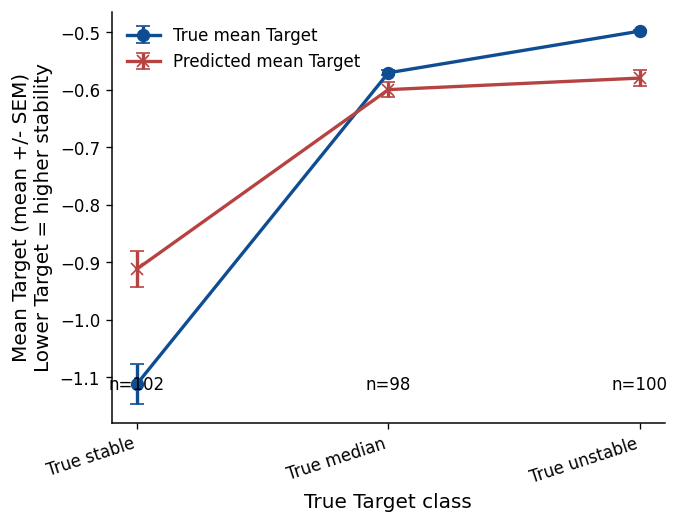

True-binned trend recovery summary:


,target_class,n,true_mean_target,predicted_mean_target,true_sem,predicted_sem
0,True stable,102,-1.111996,-0.911996,0.034862,0.031824
1,True median,98,-0.570549,-0.599817,0.004108,0.012645
2,True unstable,100,-0.498071,-0.579736,0.001470,0.014015


Figure note: The true-binned trend recovery plot checks whether the model recovers the observed stable-to-unstable Target trend.


In [12]:
def sem(values):
    values = pd.Series(values, dtype=float).dropna()
    if len(values) <= 1:
        return np.nan
    return float(values.std(ddof=1) / np.sqrt(len(values)))


def assign_target_bins(values, labels):
    values = pd.Series(values, dtype=float)
    try:
        return pd.qcut(values, q=len(labels), labels=labels)
    except ValueError:
        ranked = values.rank(method="first")
        return pd.qcut(ranked, q=len(labels), labels=labels)


def build_trend_summary(prediction_df, bin_source, labels):
    work = prediction_df.copy()
    work["target_class"] = assign_target_bins(work[bin_source], labels)
    summary = (
        work.groupby("target_class", observed=False)
        .agg(
            n=("y_true", "size"),
            true_mean_target=("y_true", "mean"),
            predicted_mean_target=("y_pred", "mean"),
            true_sem=("y_true", sem),
            predicted_sem=("y_pred", sem),
        )
        .reindex(labels)
        .reset_index()
    )
    return summary


true_labels = ["True stable", "True median", "True unstable"]
true_binned_trend_summary = build_trend_summary(test_predictions, "y_true", true_labels)
assert int(true_binned_trend_summary["n"].sum()) == len(test_predictions)

fig, ax = plt.subplots(figsize=(5.8, 4.5))
x = np.arange(len(true_labels))
ax.errorbar(
    x,
    true_binned_trend_summary["true_mean_target"],
    yerr=true_binned_trend_summary["true_sem"],
    marker="o",
    linewidth=2.0,
    markersize=7,
    capsize=4,
    label="True mean Target",
    color="#0F4D92",
)
ax.errorbar(
    x,
    true_binned_trend_summary["predicted_mean_target"],
    yerr=true_binned_trend_summary["predicted_sem"],
    marker="x",
    linewidth=2.0,
    markersize=7,
    capsize=4,
    label="Predicted mean Target",
    color="#B64342",
)
ax.set_xticks(x)
ax.set_xticklabels(true_labels, rotation=18, ha="right")
ax.set_xlabel("True Target class")
ax.set_ylabel("Mean Target (mean +/- SEM)\nLower Target = higher stability")
ymin, ymax = ax.get_ylim()
for xi, n in enumerate(true_binned_trend_summary["n"]):
    ax.text(xi, ymin + 0.07 * (ymax - ymin), f"n={int(n)}", ha="center", va="bottom", fontsize=10)
ax.legend(fontsize=10, loc="best")
ax.grid(False)
fig.tight_layout()
save_figure_if_requested(fig, "true_binned_trend_recovery")
plt.show()

print("True-binned trend recovery summary:")
display(true_binned_trend_summary.round(6))
print(
    "Figure note: The true-binned trend recovery plot checks whether the model recovers the observed stable-to-unstable Target trend."
)

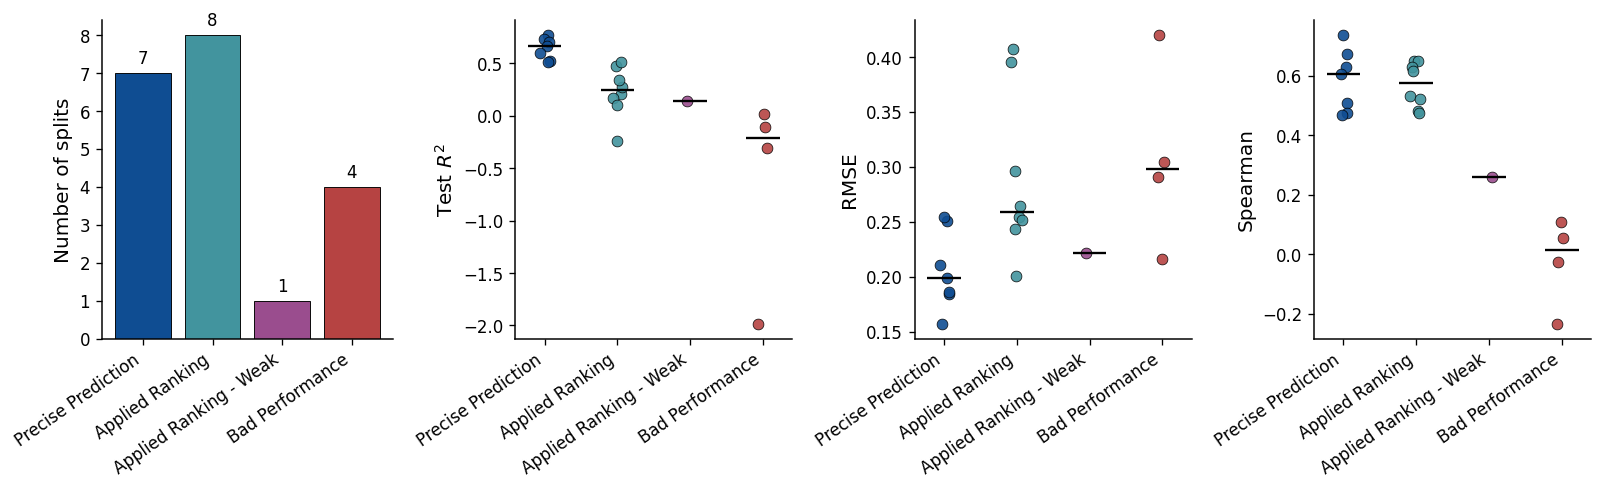

Class-level median metrics; points in the plot show individual split values:


,classification,n_splits,median_R2_test,median_RMSE_test,median_spearman_rank_corr
0,Precise Prediction,7,0.662279,0.198909,0.607143
1,Applied Ranking,8,0.243781,0.259359,0.575000
2,Applied Ranking - Weak,1,0.144416,0.221180,0.260714
3,Bad Performance,4,-0.206680,0.297731,0.014286


Figure note: Class-level performance is shown with split-level points and median lines, rather than mean bars, because each functional class contains a small number of grouped splits.


In [13]:
classification_order_for_plot = [
    c for c in CLASSIFICATION_COLORS
    if c in split_classification_summary["classification"].unique()
]
classification_counts = (
    split_classification_summary["classification"]
    .value_counts()
    .reindex(classification_order_for_plot)
    .fillna(0)
    .astype(int)
    .reset_index()
)
classification_counts.columns = ["classification", "n_splits"]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(13.5, 4.2),
    gridspec_kw={"width_ratios": [1.05, 1.0, 1.0, 1.0]},
)

count_colors = [CLASSIFICATION_COLORS.get(c, "0.5") for c in classification_counts["classification"]]
axes[0].bar(
    classification_counts["classification"],
    classification_counts["n_splits"],
    color=count_colors,
    edgecolor="black",
    linewidth=0.55,
)
axes[0].set_ylabel("Number of splits")
axes[0].tick_params(axis="x", rotation=35)
for tick in axes[0].get_xticklabels():
    tick.set_ha("right")
for x_i, y in enumerate(classification_counts["n_splits"]):
    axes[0].text(x_i, y + 0.15, str(int(y)), ha="center", va="bottom", fontsize=10)
axes[0].grid(False)

metric_specs = [
    ("R2_test", r"Test $R^2$"),
    ("RMSE_test", "RMSE"),
    ("spearman_rank_corr", "Spearman"),
]
rng = np.random.default_rng(42)
for ax, (metric, ylabel) in zip(axes[1:], metric_specs):
    for x_i, classification in enumerate(classification_order_for_plot):
        group = split_classification_summary.loc[
            split_classification_summary["classification"] == classification
        ].copy()
        if group.empty:
            continue
        jitter = rng.uniform(-0.08, 0.08, size=len(group))
        x_values = np.full(len(group), x_i, dtype=float) + jitter
        ax.scatter(
            x_values,
            group[metric],
            s=42,
            color=CLASSIFICATION_COLORS.get(classification, "0.5"),
            edgecolor="black",
            linewidth=0.45,
            alpha=0.9,
        )
        median_value = float(group[metric].median())
        ax.hlines(
            median_value,
            x_i - 0.23,
            x_i + 0.23,
            colors="black",
            linewidth=1.4,
        )
    ax.set_xticks(np.arange(len(classification_order_for_plot)))
    ax.set_xticklabels(classification_order_for_plot, rotation=35, ha="right")
    ax.set_ylabel(ylabel)
    ax.grid(False)

fig.tight_layout()
save_figure_if_requested(fig, "classification_split_level_distribution")
plt.show()

classification_metric_medians = (
    split_classification_summary
    .groupby("classification", sort=False)
    .agg(
        n_splits=("split_index", "size"),
        median_R2_test=("R2_test", "median"),
        median_RMSE_test=("RMSE_test", "median"),
        median_spearman_rank_corr=("spearman_rank_corr", "median"),
    )
    .reindex(classification_order_for_plot)
    .reset_index()
)

print("Class-level median metrics; points in the plot show individual split values:")
display(classification_metric_medians.round(6))
print(
    "Figure note: Class-level performance is shown with split-level points and median lines, "
    "rather than mean bars, because each functional class contains a small number of grouped splits."
)

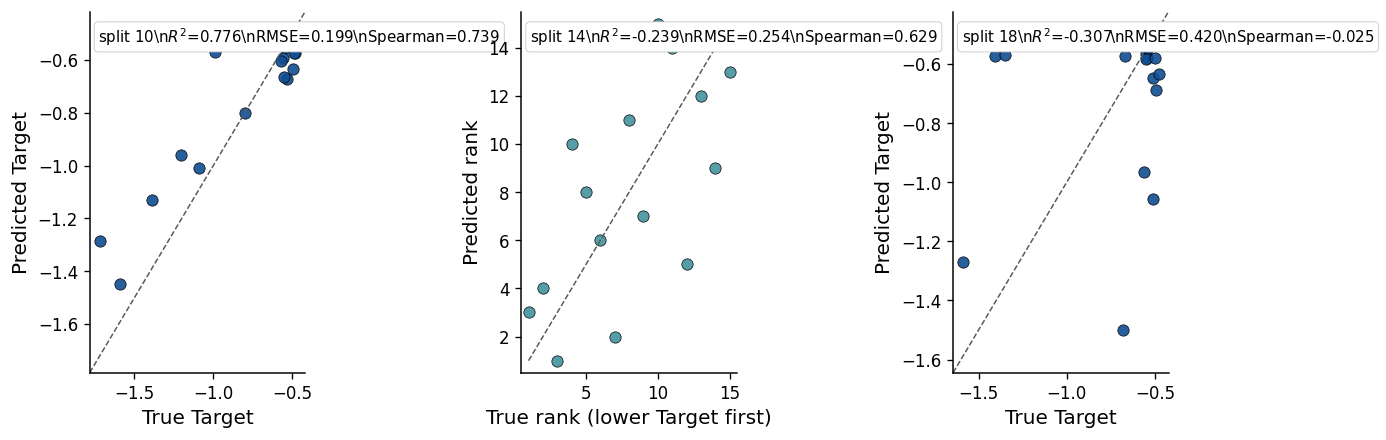

Figure note: Representative split examples illustrate functional regimes only. They should not replace the 20-split summary statistics.


In [14]:
def plot_split_parity(ax, split_index):
    pred = test_predictions[test_predictions["split_index"] == split_index].copy()
    metrics = test_metrics_by_split.loc[test_metrics_by_split["split_index"] == split_index].iloc[0]
    ax.scatter(pred["y_true"], pred["y_pred"], s=46, color="#0F4D92", edgecolor="black", linewidth=0.45, alpha=0.9)
    low = float(min(pred["y_true"].min(), pred["y_pred"].min()))
    high = float(max(pred["y_true"].max(), pred["y_pred"].max()))
    pad = 0.05 * (high - low) if high > low else 0.05
    ax.plot([low - pad, high + pad], [low - pad, high + pad], color="0.35", linestyle="--", linewidth=0.9)
    ax.set_xlim(low - pad, high + pad)
    ax.set_ylim(low - pad, high + pad)
    ax.set_xlabel("True Target")
    ax.set_ylabel("Predicted Target")
    ax.text(
        0.04,
        0.96,
        fr"split {split_index}\n$R^2$={metrics['R2_test']:.3f}\nRMSE={metrics['RMSE_test']:.3f}\nSpearman={metrics['spearman_rank_corr']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.75", linewidth=0.45),
    )
    ax.grid(False)


def plot_split_rank(ax, split_index):
    pred = test_predictions[test_predictions["split_index"] == split_index].copy()
    metrics = test_metrics_by_split.loc[test_metrics_by_split["split_index"] == split_index].iloc[0]
    ax.scatter(
        pred["true_rank_low_target_first"],
        pred["pred_rank_low_target_first"],
        s=46,
        color="#42949E",
        edgecolor="black",
        linewidth=0.45,
        alpha=0.9,
    )
    rank_min = 1
    rank_max = int(max(pred["true_rank_low_target_first"].max(), pred["pred_rank_low_target_first"].max()))
    ax.plot([rank_min, rank_max], [rank_min, rank_max], color="0.35", linestyle="--", linewidth=0.9)
    ax.set_xlim(rank_min - 0.5, rank_max + 0.5)
    ax.set_ylim(rank_min - 0.5, rank_max + 0.5)
    ax.set_xlabel("True rank (lower Target first)")
    ax.set_ylabel("Predicted rank")
    ax.text(
        0.04,
        0.96,
        fr"split {split_index}\n$R^2$={metrics['R2_test']:.3f}\nRMSE={metrics['RMSE_test']:.3f}\nSpearman={metrics['spearman_rank_corr']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.75", linewidth=0.45),
    )
    ax.grid(False)


fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.8))
plot_split_parity(axes[0], 10)
plot_split_rank(axes[1], 14)
plot_split_parity(axes[2], 18)
fig.tight_layout()
save_figure_if_requested(fig, "representative_splits")
plt.show()

print(
    "Figure note: Representative split examples illustrate functional regimes only. "
    "They should not replace the 20-split summary statistics."
)

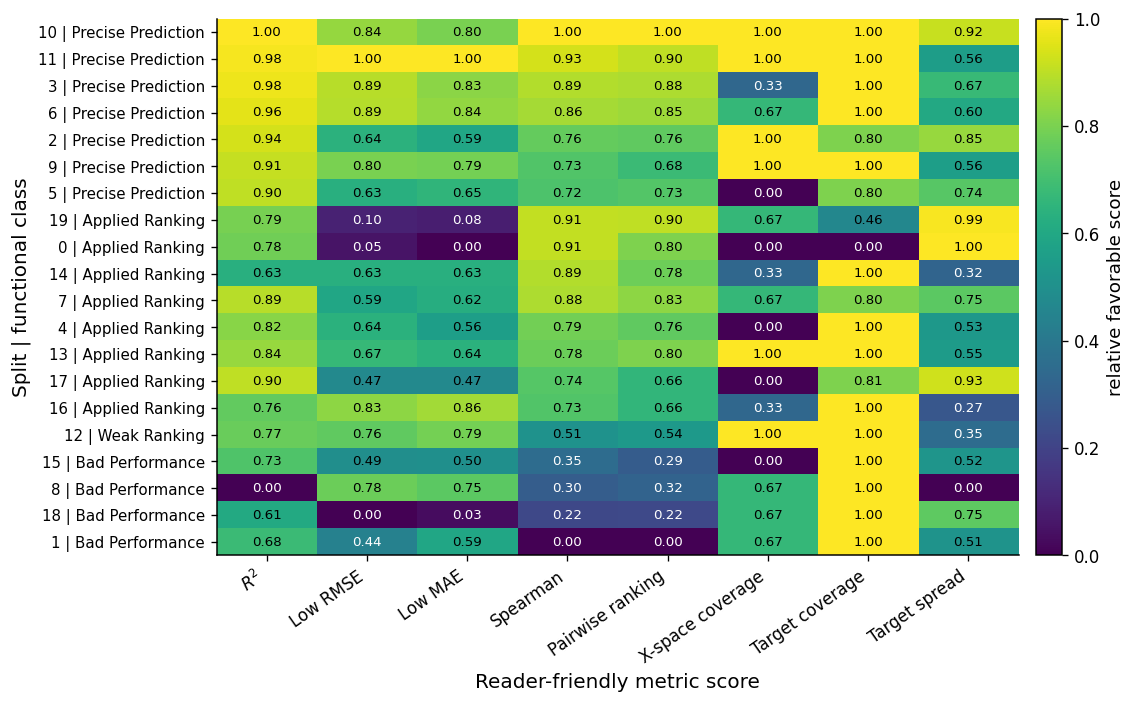

Figure note: The heatmap converts each diagnostic to a favorable-direction score. It is a compact supplementary-style overview rather than the primary evidence.


In [15]:
def minmax_score(series, higher_is_better=True):
    values = pd.Series(series, dtype=float)
    min_value = float(values.min())
    max_value = float(values.max())
    if np.isclose(max_value, min_value):
        score = pd.Series(np.ones(len(values)), index=values.index, dtype=float)
    else:
        score = (values - min_value) / (max_value - min_value)
    if not higher_is_better:
        score = 1.0 - score
    return score


heatmap_metric_map = {
    r"$R^2$": ("R2_test", True),
    "Low RMSE": ("RMSE_test", False),
    "Low MAE": ("MAE_test", False),
    "Spearman": ("spearman_rank_corr", True),
    "Pairwise ranking": ("pairwise_order_accuracy", True),
    "X-space coverage": ("n_features_outside_train_range", False),
    "Target coverage": ("test_target_range_excess", False),
    "Target spread": ("test_target_std", True),
}

heatmap_plot_df = split_classification_summary[["split_index", "classification"] + [v[0] for v in heatmap_metric_map.values()]].copy()
for label, (metric, higher_is_better) in heatmap_metric_map.items():
    heatmap_plot_df[label] = minmax_score(heatmap_plot_df[metric], higher_is_better=higher_is_better)

heatmap_labels = list(heatmap_metric_map.keys())
heatmap_matrix = heatmap_plot_df[heatmap_labels].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(9.6, 6.0))
im = ax.imshow(heatmap_matrix, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(heatmap_labels)))
ax.set_xticklabels(heatmap_labels, rotation=35, ha="right", fontsize=10)
ax.set_yticks(np.arange(len(heatmap_plot_df)))
ax.set_yticklabels([
    f"{int(row.split_index)} | {row.classification.replace('Applied Ranking - Weak', 'Weak Ranking')}"
    for row in heatmap_plot_df.itertuples(index=False)
], fontsize=9)
ax.set_xlabel("Reader-friendly metric score")
ax.set_ylabel("Split | functional class")
ax.grid(False)

for row_i in range(heatmap_matrix.shape[0]):
    for col_i in range(heatmap_matrix.shape[1]):
        value = heatmap_matrix[row_i, col_i]
        ax.text(col_i, row_i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="white" if value < 0.45 else "black")

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("relative favorable score", fontsize=11)
cbar.ax.tick_params(labelsize=10)
fig.tight_layout()
save_figure_if_requested(fig, "metric_heatmap")
plt.show()

print(
    "Figure note: The heatmap converts each diagnostic to a favorable-direction score. "
    "It is a compact supplementary-style overview rather than the primary evidence."
)

## English interpretation

The grouped split results should be interpreted as a 20-split generalization analysis rather than a single-split model report. Spearman rank correlation is used as the primary ranking metric because it directly measures whether predicted Target values preserve the true stability order. Pairwise order accuracy is retained as a secondary, application-oriented check.

The Spearman thresholds are operational thresholds for functional interpretation, not universal statistical cutoffs. In this notebook, `Spearman < 0.20` is treated as unreliable ranking, `0.20 <= Spearman < 0.45` as weak-to-moderate ranking utility, and `Spearman >= 0.45` as practically useful ranking for candidate screening. The full continuous metric values are still reported for every split.

The 3D X-space panel is a context panel showing sparse P/I/D coverage and group structure, not a quantitative performance panel. It explains why X-space grouped splits can be stricter than random splits and why extrapolation-like cases may appear.

The Test R<sup>2</sup>-vs-Spearman scatter separates numerical prediction quality from ranking utility: `Precise Prediction` splits combine useful calibration and useful ranking, whereas `Applied Ranking` splits are more appropriate for screening than exact Target prediction. Class-level performance is shown with split-level points and median lines rather than only mean bars, because the number of splits per class is small and the distribution matters.

The true-binned trend recovery plot checks whether predicted mean Target follows the stable-to-unstable ordering defined by the observed Target. This panel supports the conservative conclusion that the model often recovers relative stability trends, even though exact Target calibration is not uniformly precise across grouped splits.

Representative split plots are illustrative examples only. The main conclusion comes from all 20 X-space grouped splits. Bad-performance splits should be interpreted using the evidence columns because poor behavior can arise from X-space extrapolation, Target-space mismatch, narrow test-set Target spread, or weak rank consistency. Overall, this GPR model is most reliable for interpolation-like prediction and candidate ranking within covered P/I/D regions, and less reliable for extrapolating to underrepresented X-space or Target-space regions.